# 02 HAR-RV Baseline

This notebook fits the first forecasting baseline: a pooled HAR-RV regression with ticker fixed effects.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import Image, display

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run the data notebook first so this file exists: {MODEL_DF_PATH}'
PROJECT_DIR

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')

## HAR-RV setup

`HAR-RV` stands for `Heterogeneous Autoregressive Realized Volatility`. The model predicts future volatility from volatility measured at several recent horizons at once. In this project the predictors are based on `1d`, `5d`, and `21d` realized volatility information.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date'])
print(model_df.shape)
model_df[['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d', 'abs_return', 'realized_vol_5d', 'realized_vol_21d']].head()

(133980, 98)


,Date,Ticker,fvol_5d,log_fvol_5d,abs_return,realized_vol_5d,realized_vol_21d
0,2016-04-05,AAPL,0.197562,-1.621702,0.011859,0.181734,0.163209
1,2016-04-06,AAPL,0.209733,-1.561921,0.010419,0.152969,0.162645
2,2016-04-07,AAPL,0.139626,-1.968790,0.022051,0.215721,0.177386
3,2016-04-08,AAPL,0.200380,-1.607538,0.001105,0.205895,0.177400
4,2016-04-11,AAPL,0.252147,-1.377742,0.003308,0.194110,0.177762


## Evaluation design

The notebook uses 5-fold expanding-window time-series cross-validation. The validation years are `2020-2024`, and the final out-of-sample test year is `2025`.

In [3]:
import os
from pathlib import Path

try:
    RUNTIME_DIR = PROJECT_DIR
    mpl_dir = RUNTIME_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    RUNTIME_DIR = Path('/tmp/erdos_vol_pred_runtime')
    mpl_dir = RUNTIME_DIR / '.matplotlib'
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

import matplotlib.pyplot as plt
from IPython.display import Image, display
import statsmodels.api as sm

FIGURE_DIR = RUNTIME_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

har_config = {
    'cv_folds': 5,
    'cv_validation_years': [2020, 2021, 2022, 2023, 2024],
    'test_year': 2025,
    'target': 'log_fvol_5d',
    'har_windows': ['1d', '5d', '21d'],
    'ticker_fixed_effects': True,
    'epochs': 'not applicable for OLS-based HAR-RV',
}
har_config

{'cv_folds': 5,
 'cv_validation_years': [2020, 2021, 2022, 2023, 2024],
 'test_year': 2025,
 'target': 'log_fvol_5d',
 'har_windows': ['1d', '5d', '21d'],
 'ticker_fixed_effects': True,
 'epochs': 'not applicable for OLS-based HAR-RV'}

## Prepare the HAR-RV design matrix

The HAR-RV regression uses three volatility predictors for each stock-date row: a `1d` volatility proxy, `5d` realized volatility, and `21d` realized volatility. The regression is fitted on the log scale and includes ticker fixed effects.

In [4]:
har_df = model_df[['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d', 'abs_return', 'realized_vol_5d', 'realized_vol_21d']].copy()

# Daily / weekly / monthly HAR-style predictors.
har_df['har_rv_1d'] = np.sqrt(252.0) * har_df['abs_return']
har_df['har_rv_5d'] = har_df['realized_vol_5d']
har_df['har_rv_21d'] = har_df['realized_vol_21d']

# Regress on log-volatility so the target is more symmetric and stable.
har_df['log_har_rv_1d'] = np.log(har_df['har_rv_1d'].clip(lower=1e-8))
har_df['log_har_rv_5d'] = np.log(har_df['har_rv_5d'].clip(lower=1e-8))
har_df['log_har_rv_21d'] = np.log(har_df['har_rv_21d'].clip(lower=1e-8))

ticker_levels = sorted(har_df['Ticker'].unique())
selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']

har_df.head()

,Date,Ticker,fvol_5d,log_fvol_5d,abs_return,realized_vol_5d,realized_vol_21d,har_rv_1d,har_rv_5d,har_rv_21d,log_har_rv_1d,log_har_rv_5d,log_har_rv_21d
0,2016-04-05,AAPL,0.197562,-1.621702,0.011859,0.181734,0.163209,0.188258,0.181734,0.163209,-1.669943,-1.705210,-1.812726
1,2016-04-06,AAPL,0.209733,-1.561921,0.010419,0.152969,0.162645,0.165389,0.152969,0.162645,-1.799453,-1.877518,-1.816184
2,2016-04-07,AAPL,0.139626,-1.968790,0.022051,0.215721,0.177386,0.350050,0.215721,0.177386,-1.049680,-1.533771,-1.729428
3,2016-04-08,AAPL,0.200380,-1.607538,0.001105,0.205895,0.177400,0.017540,0.205895,0.177400,-4.043285,-1.580389,-1.729347
4,2016-04-11,AAPL,0.252147,-1.377742,0.003308,0.194110,0.177762,0.052506,0.194110,0.177762,-2.946832,-1.639329,-1.727312


In [5]:
def build_har_design_matrix(df, ticker_levels, use_ticker_fixed_effects=True):
    """
    Build the regression matrix for HAR-RV.

    The first three columns are the HAR volatility inputs. If fixed effects are
    enabled, we append one-hot ticker dummies (dropping the first ticker to
    avoid perfect multicollinearity).
    """
    X = df[['log_har_rv_1d', 'log_har_rv_5d', 'log_har_rv_21d']].reset_index(drop=True).copy()

    if use_ticker_fixed_effects:
        ticker_cat = pd.Categorical(df['Ticker'], categories=ticker_levels)
        ticker_dummies = pd.get_dummies(ticker_cat, prefix='ticker', drop_first=True, dtype=float)
        X = pd.concat([X, ticker_dummies.reset_index(drop=True)], axis=1)

    X = sm.add_constant(X, has_constant='add')
    return X


def volatility_metrics(y_true, y_pred):
    """Evaluate forecasts on the original volatility scale."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
    }


def fit_har_rv(train_df, predict_df, ticker_levels, use_ticker_fixed_effects=True):
    X_train = build_har_design_matrix(train_df, ticker_levels, use_ticker_fixed_effects)
    X_predict = build_har_design_matrix(predict_df, ticker_levels, use_ticker_fixed_effects)
    y_train = train_df['log_fvol_5d'].reset_index(drop=True)
    model = sm.OLS(y_train, X_train).fit()
    log_pred = model.predict(X_predict)
    pred = np.exp(log_pred)
    return model, pred

## 5-fold time-series cross-validation

Each fold trains on all data strictly before the validation year and validates only on that year.

In [6]:
cv_rows = []

for fold_number, validation_year in enumerate(har_config['cv_validation_years'], start=1):
    train_fold = har_df[har_df['Date'].dt.year < validation_year].copy()
    validation_fold = har_df[har_df['Date'].dt.year == validation_year].copy()

    model, validation_pred = fit_har_rv(
        train_fold,
        validation_fold,
        ticker_levels=ticker_levels,
        use_ticker_fixed_effects=har_config['ticker_fixed_effects'],
    )

    metrics = volatility_metrics(validation_fold['fvol_5d'], validation_pred)
    cv_rows.append(
        {
            'fold': fold_number,
            'validation_year': validation_year,
            'train_rows': len(train_fold),
            'validation_rows': len(validation_fold),
            **metrics,
        }
    )

cv_results_df = pd.DataFrame(cv_rows)
cv_results_df

,fold,validation_year,train_rows,validation_rows,rmse,mae,qlike
0,1,2020,51810,13420,0.309175,0.174821,0.527469
1,2,2021,65230,13860,0.116329,0.079657,-1.640414
2,3,2022,79090,13805,0.166013,0.108911,-0.858731
3,4,2023,92895,13750,0.125361,0.079595,-1.659128
4,5,2024,106645,13860,0.146037,0.087457,-1.517431


In [7]:
cv_summary = pd.DataFrame(
    {
        'metric': ['rmse', 'mae', 'qlike'],
        'mean_across_folds': [cv_results_df['rmse'].mean(), cv_results_df['mae'].mean(), cv_results_df['qlike'].mean()],
        'std_across_folds': [cv_results_df['rmse'].std(), cv_results_df['mae'].std(), cv_results_df['qlike'].std()],
    }
)
cv_summary

,metric,mean_across_folds,std_across_folds
0,rmse,0.172583,0.078739
1,mae,0.106088,0.040249
2,qlike,-1.029647,0.930193


## Final training and 2025 test predictions

After cross-validation, the model is refit on all data through 2024 and evaluated on the 2025 holdout set.

In [8]:
final_train_df = har_df[har_df['Date'].dt.year < har_config['test_year']].copy()
test_df = har_df[har_df['Date'].dt.year == har_config['test_year']].copy()

final_har_model, test_pred = fit_har_rv(
    final_train_df,
    test_df,
    ticker_levels=ticker_levels,
    use_ticker_fixed_effects=har_config['ticker_fixed_effects'],
)

test_predictions_df = test_df[['Date', 'Ticker', 'fvol_5d']].reset_index(drop=True).copy()
test_predictions_df['har_rv_pred'] = np.asarray(test_pred, dtype=float)

test_metrics_df = pd.DataFrame([volatility_metrics(test_predictions_df['fvol_5d'], test_predictions_df['har_rv_pred'])])
test_metrics_df

,rmse,mae,qlike
0,0.170921,0.101005,-1.176187


## Plot predictions for representative stocks

The final plot compares the predicted and realized future 5-day volatility for representative names in the 2025 test set.

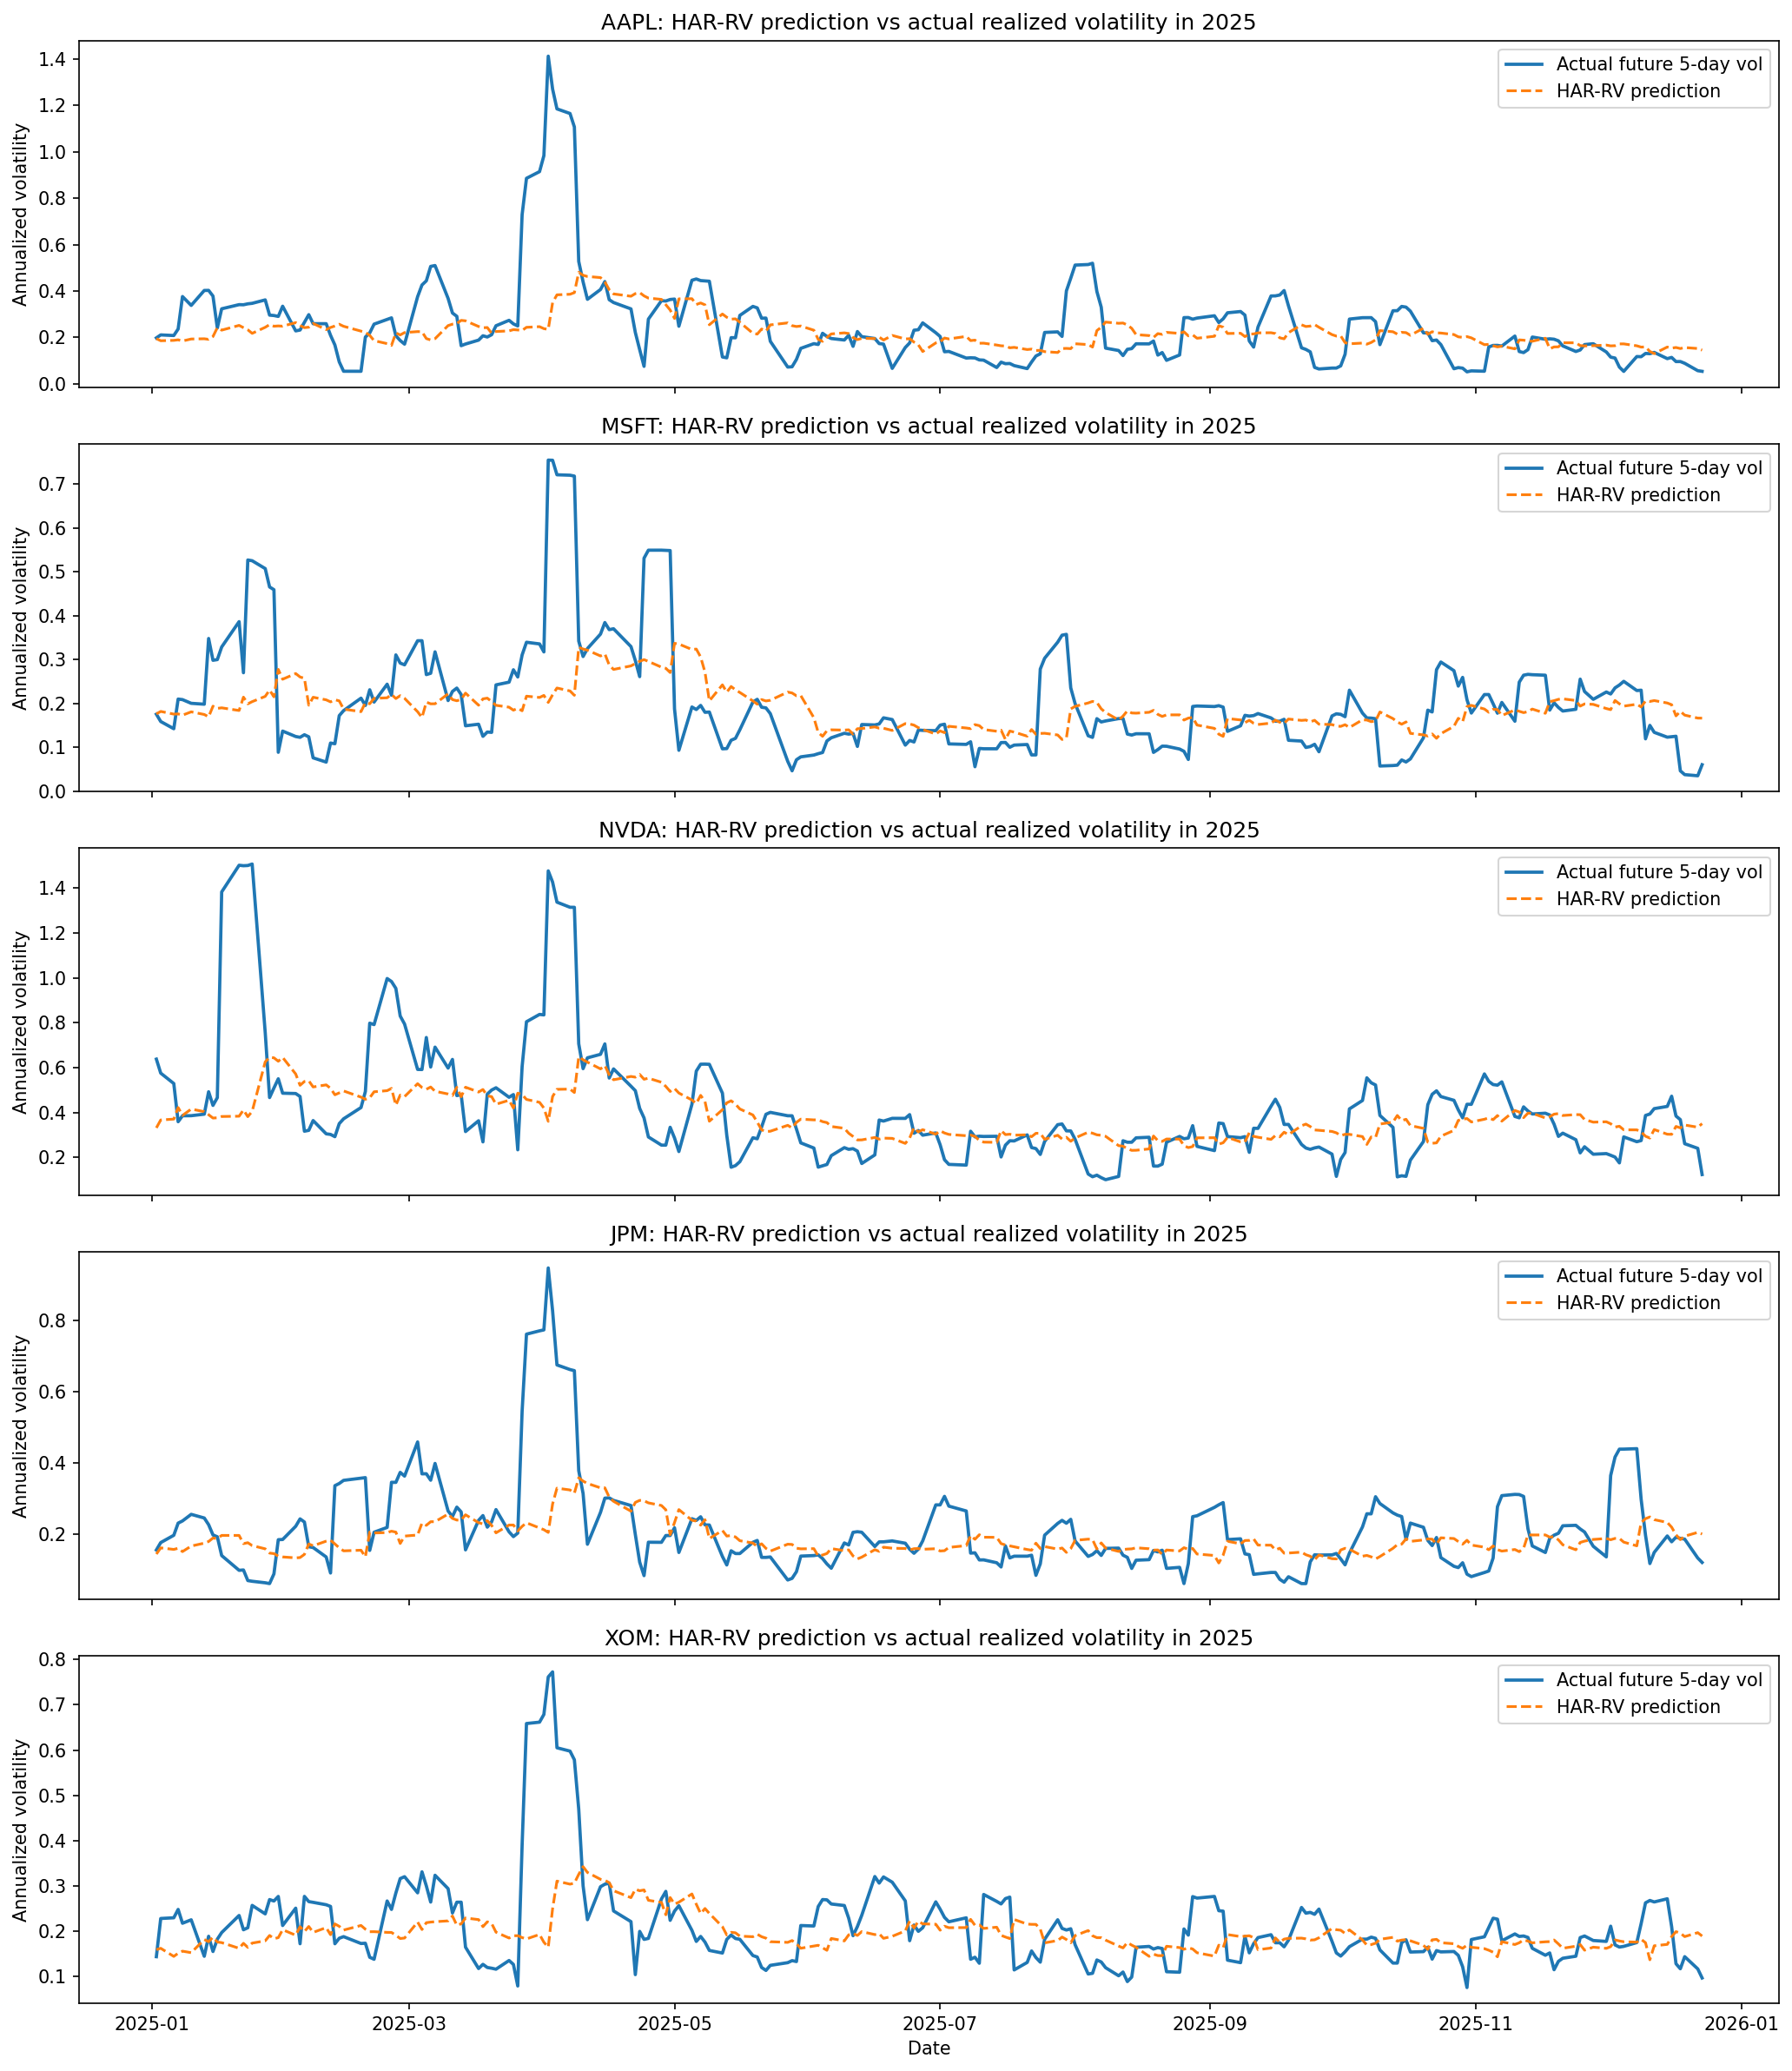

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/har_rv_test_predictions_5stocks.png')

In [9]:
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = test_predictions_df[test_predictions_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['har_rv_pred'], label='HAR-RV prediction', linestyle='--', linewidth=1.5)
    ax.set_title(f'{ticker}: HAR-RV prediction vs actual realized volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

har_plot_path = FIGURE_DIR / 'har_rv_test_predictions_5stocks.png'
plt.savefig(har_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(har_plot_path)))

har_plot_path

## Interpretation

HAR-RV is intentionally smooth because it uses rolling volatility inputs across several horizons. As a result, it often reacts more slowly than the realized series at turning points.

## Role in the project

This notebook establishes the classical financial baseline for the later machine learning and sequence-model comparisons.